In [2]:
!pip install requests



   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   ------------------------ --------------- 3/5 [certifi]
   -------------------------------- ------- 4/5 [requests]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


# Taller Regresión Lineal - Predicción de Ventas
**CADI:** Introducción a Machine Learning  
**Autor:** Ferley Antonio Moreno Cruz  
  

## 1. Definición del Problema y Recolección de Datos
Dentro del aprendizaje supervisado, la regresión se utiliza cuando queremos predecir valores numéricos continuos, encontrando la relación matemática entre las variables de entrada (predictoras) y una variable de salida. 

El objetivo de este proyecto es implementar un modelo de **Regresión Lineal**, el cual modela la relación entre variables mediante una línea recta, para predecir las ventas de un producto (variable continua) basándonos en la inversión publicitaria realizada en diferentes medios. 

A continuación, utilizamos la librería `requests` para extraer el dataset público "Advertising" directamente desde la web, cargándolo en un DataFrame de `pandas` para su posterior procesamiento.

In [10]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.4 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 17.4 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/37.4 MB 34.5 MB/s eta 0:00:01
   --------------- ------------------------ 14.4/37.4 MB 34.3 MB/s eta 0:00:01
   --------------------- ------------------ 19.7/37.4 MB 34.2 MB/s eta 0:00:01
   ------------------------- -------------- 23.9/37.4 MB 28.9 MB/s eta 0:00:01
   ------------------------------------ --- 33.8/37.4 MB 32.5 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 30.0 MB/s  0:00:01

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
  

In [6]:
import requests
import pandas as pd
import io

# URL del dataset abierto de Ventas vs Publicidad
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
print("Conectando y descargando datos (Open Data)...")
respuesta = requests.get(url)

if respuesta.status_code == 200:
    # Leer los datos directamente a un DataFrame de Pandas
    df = pd.read_csv(io.StringIO(respuesta.text), index_col=0)
    print("¡Datos recolectados exitosamente!\n")
    print("Dimensiones del dataset:", df.shape)
    display(df.head())
else:
    print(f"Error al conectar. Código de estado: {respuesta.status_code}")

Conectando y descargando datos (Open Data)...
¡Datos recolectados exitosamente!

Dimensiones del dataset: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 2. Diccionario de Variables y Análisis Exploratorio (EDA)
Para comprender la naturaleza de nuestros datos antes de modelar, definiremos las variables y realizaremos un análisis exploratorio. Esto nos permitirá identificar qué variables independientes (predictoras) tienen mayor correlación con nuestra variable objetivo, ayudándonos a entender los patrones subyacentes.

*   **Variable Objetivo Continua (Y):** `Sales` (Ventas del producto en miles de unidades).
*   **Variables Predictoras (X):** 
    *   `TV`: Inversión publicitaria en televisión (miles de dólares).
    *   `Radio`: Inversión publicitaria en radio (miles de dólares).
    *   `Newspaper`: Inversión publicitaria en periódicos (miles de dólares).

A continuación, calcularemos estadísticos descriptivos y generaremos una matriz de correlación para identificar la variable con mayor influencia en las ventas.

=== ESTADÍSTICOS DESCRIPTIVOS ===


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000



=== MATRIZ DE CORRELACIÓN ===


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


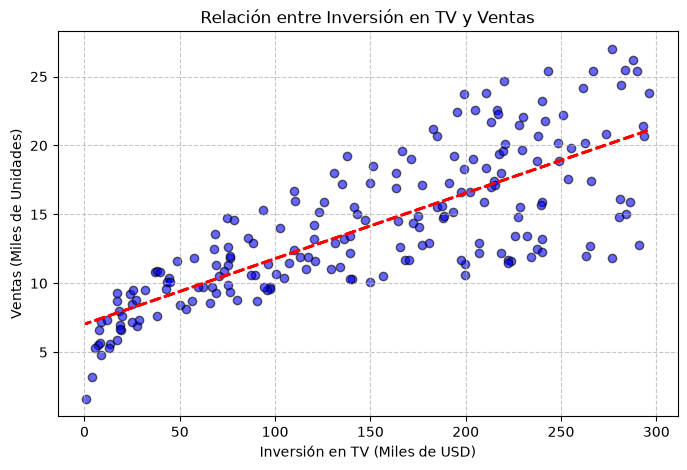

In [7]:
import matplotlib.pyplot as plt

# 1. Estadísticos descriptivos
print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
display(df.describe())

# 2. Matriz de Correlación
print("\n=== MATRIZ DE CORRELACIÓN ===")
correlacion = df.corr()
display(correlacion)

# 3. Visualización (Gráfico de dispersión)
# Graficamos la variable predictora con mayor correlación (TV) contra las Ventas
plt.figure(figsize=(8, 5))
plt.scatter(df['TV'], df['Sales'], color='blue', alpha=0.6, edgecolors='black')
plt.title('Relación entre Inversión en TV y Ventas')
plt.xlabel('Inversión en TV (Miles de USD)')
plt.ylabel('Ventas (Miles de Unidades)')
plt.grid(True, linestyle='--', alpha=0.7)

# Opcional: Mostrar una línea de tendencia básica para ilustrar la linealidad
import numpy as np
z = np.polyfit(df['TV'], df['Sales'], 1)
p = np.poly1d(z)
plt.plot(df['TV'], p(df['TV']), "r--", linewidth=2)

plt.show()

## 3. Modelado: Regresión Lineal (Train/Test)
Para construir nuestro modelo, primero dividiremos el dataset en dos conjuntos: Entrenamiento (Train) y Prueba (Test), destinando el 30% de los datos para prueba, tal como sugieren las buenas prácticas de Scikit-Learn.

Fijaremos una semilla de aleatoriedad (`random_state=42`) para garantizar que el experimento sea replicable y consistente. Posteriormente, ajustaremos un modelo de Regresión Lineal Múltiple utilizando todas las variables predictoras (TV, Radio, Newspaper) para estimar las ventas.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Separar variables predictoras (X) y la variable objetivo (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 2. Dividir en Train/Test con semilla de aleatoriedad fijada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

# 3. Inicializar y entrenar el modelo de Regresión Lineal
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

# 4. Hacer predicciones sobre el conjunto de prueba
y_pred = modelo_regresion.predict(X_test)

# 5. Evaluación de Métricas de Error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== EVALUACIÓN DEL MODELO (MÉTRICAS) ===")
print(f"MAE (Error Absoluto Medio): {mae:.4f}")
print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")

# Extra: Ver los coeficientes (pesos) asignados a cada medio publicitario
print("\n=== COEFICIENTES DEL MODELO ===")
coeficientes = pd.DataFrame({'Variable': X.columns, 'Coeficiente': modelo_regresion.coef_})
display(coeficientes)

Tamaño del conjunto de entrenamiento: (140, 3)
Tamaño del conjunto de prueba: (60, 3)

=== EVALUACIÓN DEL MODELO (MÉTRICAS) ===
MAE (Error Absoluto Medio): 1.5117
MSE (Error Cuadrático Medio): 3.7968
RMSE (Raíz del Error Cuadrático Medio): 1.9485
R² (Coeficiente de Determinación): 0.8609

=== COEFICIENTES DEL MODELO ===


,Variable,Coeficiente
0,TV,0.044059
1,Radio,0.199287
2,Newspaper,0.006882


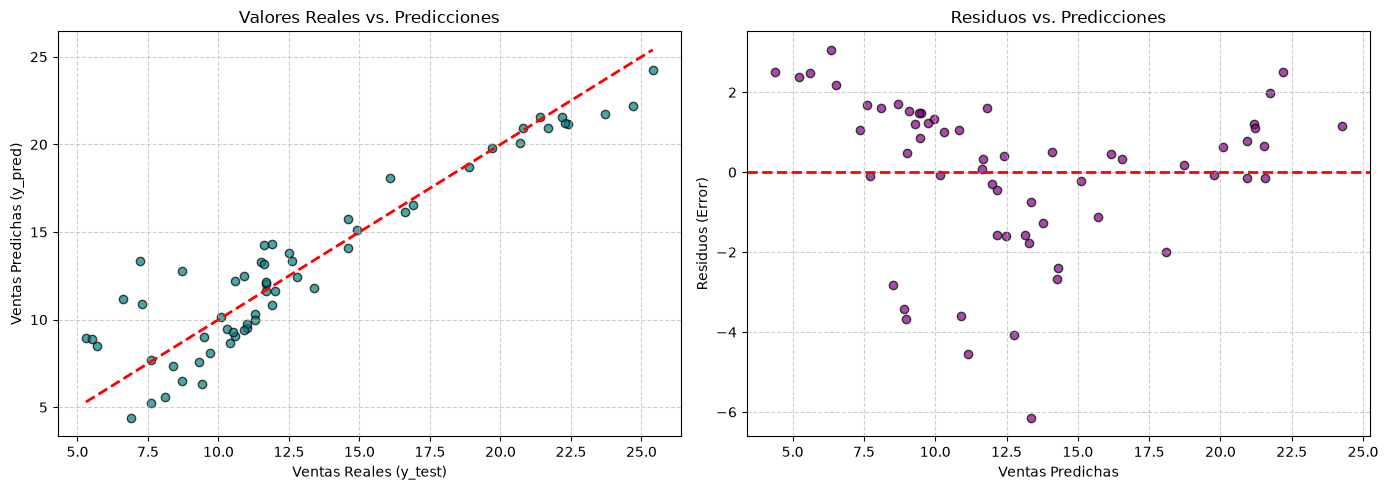

In [12]:
import matplotlib.pyplot as plt

# 1. Calcular los residuos (Error: Valor Real - Valor Predicho)
residuos = y_test - y_pred

# 2. Configurar la figura con dos gráficos en paralelo
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Valores Reales vs Predicciones (Dispersión + Recta ideal)
ax[0].scatter(y_test, y_pred, color='teal', edgecolors='black', alpha=0.7)
# Dibujamos la recta ideal (donde la predicción es exactamente igual a la realidad)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
ax[0].set_title('Valores Reales vs. Predicciones')
ax[0].set_xlabel('Ventas Reales (y_test)')
ax[0].set_ylabel('Ventas Predichas (y_pred)')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Residuos vs Predicciones (Validación de Homocedasticidad)
ax[1].scatter(y_pred, residuos, color='purple', edgecolors='black', alpha=0.7)
# Línea base en el error 0
ax[1].axhline(y=0, color='r', linestyle='--', lw=2)
ax[1].set_title('Residuos vs. Predicciones')
ax[1].set_xlabel('Ventas Predichas')
ax[1].set_ylabel('Residuos (Error)')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Conclusiones y Trabajo Futuro

**Hallazgos Principales:** 
El modelo de regresión lineal múltiple demostró un desempeño muy sólido, logrando un coeficiente de determinación ($R^2$) de 0.8609. Esto indica que aproximadamente el 86% de la variabilidad en las ventas se explica por la inversión en los diferentes canales publicitarios. Analizando los coeficientes, se evidenció que la inversión en **Radio y TV** son los predictores más relevantes para impulsar las ventas.

**Validación de Supuestos:**
Al observar el gráfico de "Residuos vs. Predicciones", notamos que los errores se distribuyen de manera relativamente aleatoria alrededor del cero (línea roja), sin formar patrones de embudo muy marcados, lo que sugiere que se cumple aceptablemente el supuesto de homocedasticidad.

**Sesgos, Limitaciones y Mejoras Futuras:**
*   **Limitación:** El coeficiente asignado a la inversión en "Newspaper" (Periódico) es extremadamente bajo (0.006), lo que sugiere que aporta poco valor predictivo.
*   **Trabajo Futuro:** Como mejora al modelo, se propone realizar una selección de características eliminando la variable `Newspaper` para reentrenar el modelo, buscando un algoritmo más simple y menos propenso al ruido. Además, se podrían evaluar modelos de ensamblaje (como Random Forest) para capturar posibles relaciones no lineales.